In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree,export_text
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

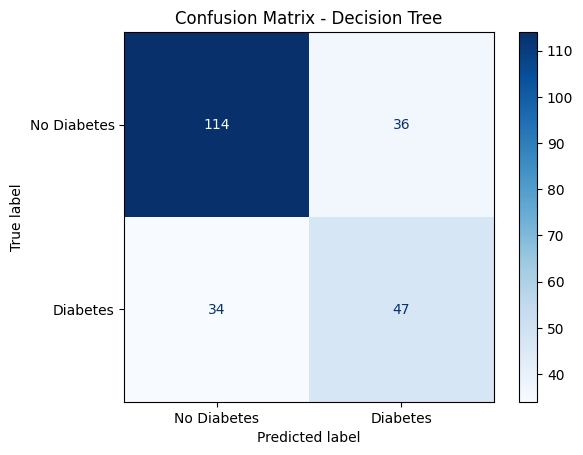

<function classification_report at 0x0000024036E2BC10> (766    1
748    1
42     0
485    1
543    0
      ..
188    1
8      1
645    0
381    0
314    1
Name: Outcome, Length: 231, dtype: int64, array([1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1]))


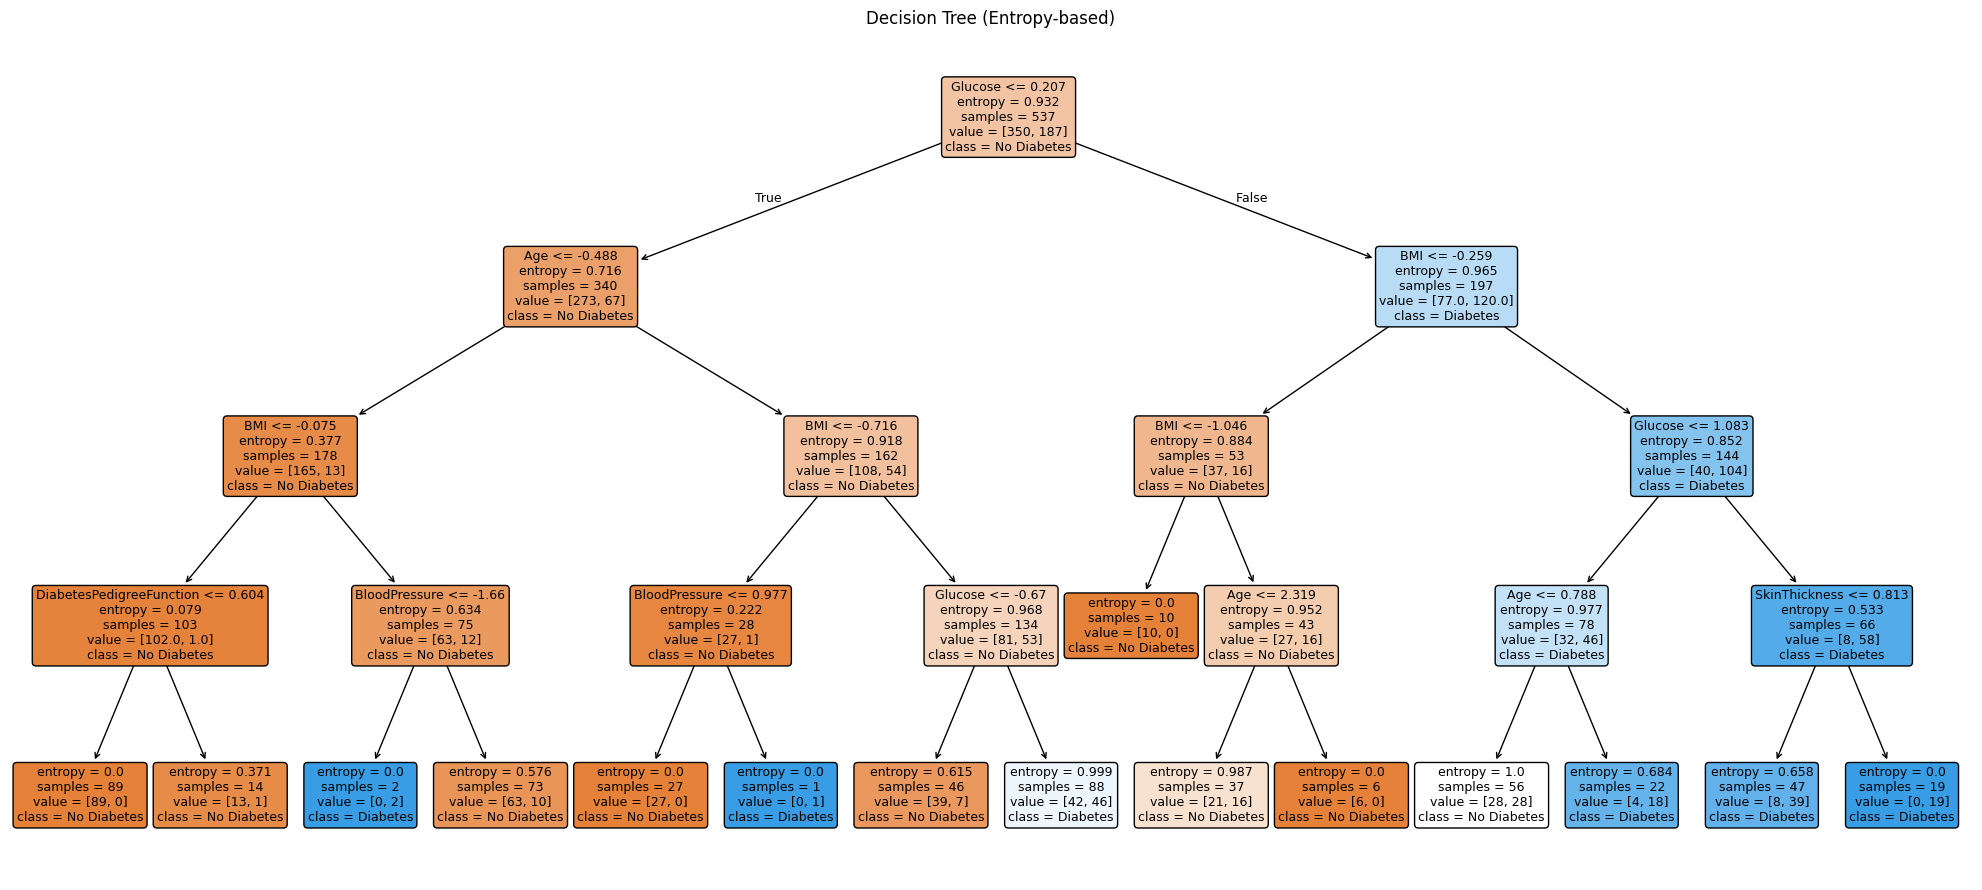

In [5]:
df = pd.read_csv('diabetes.csv')
df

x = df.drop('Outcome',axis = 1)

y = df['Outcome']

scaler = StandardScaler()
x[x.columns] = scaler.fit_transform(x[x.columns])

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state = 101)
model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

model.fit(x_train,y_train)

y_pred = model.predict(x_test)
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels = ["No Diabetes","Diabetes"]).plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()
print(classification_report,(y_test,y_pred))

plt.figure(figsize=(20,9))
plot_tree(model, feature_names=x.columns, class_names=["No Diabetes","Diabetes"],filled=True, rounded = True, fontsize=9)
plt.title("Decision Tree (Entropy-based)")
plt.tight_layout()
plt.show()
